In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow.keras import layers
from keras.layers import Dense,Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
import glob

In [2]:
train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory('C:\\Users\\Dell\\Desktop\\Dataset\\Train', target_size=(224,224), batch_size=32,
        classes = ['BabyCry', 'Bark', 'Cough', 'Dishes', 'Doorbell', 'FireAlarm', 'SmokeDetector', 'Sneeze', 'Thunder', 'Water'], shuffle = True)
validation_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory('C:\\Users\\Dell\\Desktop\\Dataset\\Validation', target_size=(224,224), batch_size=32,
        classes = ['BabyCry', 'Bark', 'Cough', 'Dishes', 'Doorbell', 'FireAlarm', 'SmokeDetector', 'Sneeze', 'Thunder', 'Water'], shuffle = True)
test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory('C:\\Users\\Dell\\Desktop\\Dataset\\Test', target_size=(224,224), batch_size=32,
        classes = ['BabyCry', 'Bark', 'Cough', 'Dishes', 'Doorbell', 'FireAlarm', 'SmokeDetector', 'Sneeze', 'Thunder', 'Water'], shuffle = False)

Found 4890 images belonging to 10 classes.
Found 524 images belonging to 10 classes.
Found 524 images belonging to 10 classes.


In [3]:
img, l = next(train_batches)

In [4]:
def plotImages(images):
    fig, axes = plt.subplots(1, 10, figsize = (20,20))
    axes = axes.flatten()
    for img, ax in zip(images,axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

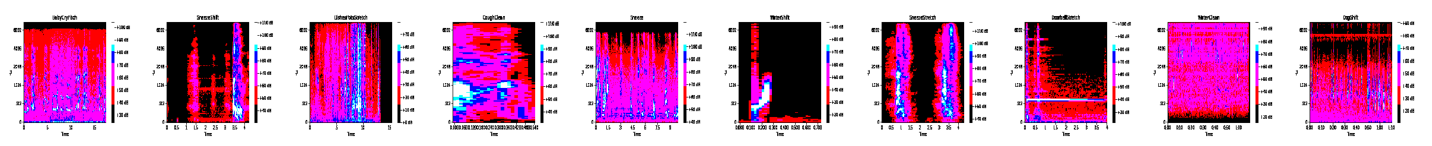

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0.

In [5]:
plotImages(img)
print(l)

In [6]:
vgg_model = tf.keras.applications.vgg16.VGG16()

In [7]:
vgg_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [8]:
model = Sequential()
for layer in vgg_model.layers[:-1]:
    model.add(layer)

In [9]:
for layer in model.layers:
    layer.trainable = False

In [10]:
model.add(Dense(units = 10, activation = 'softmax'))

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0         
                                                                 
 block3_conv1 (Conv2D)       (None, 56, 56, 256)       2

In [12]:
model.compile(optimizer = Adam(learning_rate = 0.001), loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [13]:
model.fit(x=train_batches, validation_data = validation_batches, epochs = 15)

Epoch 1/15
153/153 [==============================] - 1818s 12s/step - loss: 1.4744 - accuracy: 0.5078 - val_loss: 1.6503 - val_accuracy: 0.4141
Epoch 2/15
153/153 [==============================] - 1779s 12s/step - loss: 1.0037 - accuracy: 0.6626 - val_loss: 1.7202 - val_accuracy: 0.5324
Epoch 3/15
153/153 [==============================] - 1759s 12s/step - loss: 0.8392 - accuracy: 0.7160 - val_loss: 1.5184 - val_accuracy: 0.4771
Epoch 4/15
153/153 [==============================] - 1760s 12s/step - loss: 0.6984 - accuracy: 0.7701 - val_loss: 1.4057 - val_accuracy: 0.5210
Epoch 5/15
153/153 [==============================] - 1738s 11s/step - loss: 0.6134 - accuracy: 0.8098 - val_loss: 1.4220 - val_accuracy: 0.5477
Epoch 6/15
153/153 [==============================] - 1736s 11s/step - loss: 0.5647 - accuracy: 0.8143 - val_loss: 1.3677 - val_accuracy: 0.5267
Epoch 7/15
153/153 [==============================] - 999s 7s/step - loss: 0.5177 - accuracy: 0.8321 - val_loss: 1.3081 - val_accu

In [14]:
predictions = model.predict(x = test_batches, verbose = 1)

17/17 [==============================] - 94s 5s/step


In [15]:
from sklearn import metrics

In [16]:
predictions

array([[3.78563851e-01, 4.31426056e-02, 8.74104258e-03, ...,
        4.40963984e-01, 1.32715082e-04, 4.28148778e-03],
       [2.25961715e-01, 5.75120933e-02, 1.30008124e-02, ...,
        4.01394933e-01, 1.15170050e-03, 5.89001505e-03],
       [8.83780658e-01, 2.89486465e-03, 2.56159855e-03, ...,
        6.95048794e-02, 6.32467505e-04, 1.23337070e-02],
       ...,
       [2.70095631e-03, 4.06628475e-02, 2.19459847e-01, ...,
        2.19455920e-02, 6.77206926e-03, 6.80199921e-01],
       [1.43563235e-02, 7.56610942e-04, 1.42476307e-02, ...,
        2.58276723e-02, 1.70234218e-02, 3.90332431e-01],
       [3.24809778e-04, 4.44267316e-05, 3.05561116e-03, ...,
        1.03617227e-03, 9.77601085e-05, 8.83066118e-01]], dtype=float32)

In [18]:
metrics.accuracy_score(test_batches.classes, np.argmax(predictions, axis = -1))

0.5629770992366412

In [19]:
np.argmax(predictions, axis = -1)

array([7, 7, 0, 9, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 9, 0, 0, 0, 0, 0,
       0, 4, 0, 0, 1, 7, 0, 0, 9, 0, 0, 0, 9, 0, 0, 7, 0, 0, 8, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 9, 1, 1, 1, 7, 1, 1, 7, 1, 0, 1, 9, 1, 7, 1, 1, 2, 6,
       1, 1, 0, 1, 7, 1, 1, 1, 1, 7, 1, 1, 2, 1, 1, 9, 9, 1, 1, 1, 1, 0,
       6, 9, 8, 1, 9, 1, 1, 1, 0, 7, 2, 1, 2, 8, 1, 7, 6, 7, 2, 2, 0, 3,
       2, 1, 0, 9, 3, 2, 9, 2, 7, 0, 9, 9, 7, 9, 2, 7, 1, 0, 3, 9, 2, 2,
       2, 0, 0, 9, 1, 9, 1, 4, 1, 7, 9, 2, 2, 9, 4, 9, 6, 4, 9, 1, 2, 7,
       7, 7, 2, 7, 5, 9, 9, 2, 9, 9, 6, 9, 3, 3, 3, 9, 3, 6, 9, 9, 3, 9,
       7, 9, 6, 9, 0, 3, 9, 9, 2, 3, 9, 9, 3, 6, 9, 9, 3, 9, 9, 9, 3, 6,
       9, 3, 9, 6, 9, 3, 2, 6, 3, 9, 3, 3, 3, 9, 9, 6, 9, 3, 3, 9, 4, 4,
       5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 0, 4, 9, 4, 5, 6, 3, 9, 6, 6, 9, 5, 6, 5, 5, 8, 5, 5, 9, 4, 5,
       5, 4, 5, 5, 9, 4, 6, 6, 5, 5, 5, 4, 3, 5, 5,

In [20]:
test_batches.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,

In [21]:
import os.path
model.save("D:\\SavedModels\\vgg16Latest.h5")

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
model2 = load_model("D:\\SavedModels\\vgg16_4Classes_DogCatBaby2")

In [ ]:
model2.summary()

In [ ]:
model2.get_weights()

In [ ]:
model2.optimizer

In [ ]:
predictions = model2.predict(x = test_batches, verbose = 1)

In [ ]:
sklearn.metrics.accuracy_score(test_batches.classes, np.argmax(predictions, axis = -1))